In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Load data
print("\n[1/7] Loading data...")
file_path = 'data.xlsx'  # Change to your file path
df = pd.read_excel(file_path)
print(f"✓ Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Data overview
print(f"\nColumn dtypes breakdown:\n{df.dtypes.value_counts().to_string()}")
print(f"Total missing values: {df.isnull().sum().sum()}")
missing = df.isnull().sum()
if missing.any():
    print(f"Columns with missing values:\n{missing[missing > 0].to_string()}")

# Data preprocessing
print("\n[2/7] Preprocessing data...")
if 'Due Date' in df.columns:
    df['Due Date'] = pd.to_datetime(df['Due Date'], errors='coerce')
    df['Days_to_Due'] = (df['Due Date'] - pd.Timestamp.now()).dt.days
    df['Months_to_Due'] = df['Days_to_Due'] / 30
    df['Years_to_Due'] = df['Days_to_Due'] / 365
    df = df.drop('Due Date', axis=1)

# Handle missing values
df = df.fillna(df.median(numeric_only=True))
print(f"✓ Missing values filled with column medians")



[1/7] Loading data...
✓ Data loaded: 532,481 rows, 10 columns

Column dtypes breakdown:
float64    8
int64      2
Total missing values: 0

[2/7] Preprocessing data...
✓ Missing values filled with column medians


In [3]:
# Feature Engineering
print("\n[3/7] Engineering features...")

# Create ratio and interaction features
df['Rate_Difference'] = df['Effec. Rate'] - df['Flat Rate']
df['Rental_to_Amount_Ratio'] = df['Net Rental'] / (df['Facility amount'] + 1)
df['Amount_per_Tenor'] = df['Facility amount'] / (df['Tenor'] + 1)
df['Rental_per_Tenor'] = df['Net Rental'] / (df['Tenor'] + 1)
df['Arrears_Rate'] = df['No of Rental in arrears'] / (df['Tenor'] + 1)
df['Total_Payment'] = df['Net Rental'] * df['Tenor']
df['Payment_Capacity'] = df['Facility amount'] / (df['Total_Payment'] + 1)
df['Risk_Score'] = df['No of Rental in arrears'] * df['Effec. Rate'] / 100
df['Age_Tenor_Interaction'] = df['Age'] * df['Tenor']
df['Amount_Rate_Interaction'] = df['Facility amount'] * df['Effec. Rate'] / 100
df['Arrears_Amount'] = df['No of Rental in arrears'] * df['Net Rental']

# Logarithmic features for skewed data
df['Log_Facility_Amount'] = np.log1p(df['Facility amount'])
df['Log_Net_Rental'] = np.log1p(df['Net Rental'])

# Squared features
df['Tenor_Squared'] = df['Tenor'] ** 2
df['Age_Squared'] = df['Age'] ** 2
df['Arrears_Squared'] = df['No of Rental in arrears'] ** 2

# Polynomial features for key variables
df['Rate_Squared'] = df['Effec. Rate'] ** 2
df['Rate_Cubed'] = df['Effec. Rate'] ** 3

print(f"✓ Features created: {df.shape[1]} total features")


[3/7] Engineering features...
✓ Features created: 30 total features


In [4]:
# Separate features and targets
target_columns = ['Impairment', '1 yr ECL']
feature_columns = [col for col in df.columns if col not in target_columns]

X = df[feature_columns]
y_impairment = df['Impairment']
y_ecl = df['1 yr ECL']

# Split data (80-20 split for large dataset)
X_train, X_test, y_imp_train, y_imp_test = train_test_split(
    X, y_impairment, test_size=0.2, random_state=42
)
_, _, y_ecl_train, y_ecl_test = train_test_split(
    X, y_ecl, test_size=0.2, random_state=42
)

print(f"✓ Train set: {len(X_train):,} samples | Test set: {len(X_test):,} samples")

✓ Train set: 425,984 samples | Test set: 106,497 samples


In [5]:

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
try:
    joblib.dump(scaler, 'scaler_advanced.pkl')
    print("Scaler saved successfully ✅")
except Exception as e:
    print("Error saving scaler:", e)

# Define advanced models with optimized hyperparameters
print("\n[4/7] Initializing advanced models...")

models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=500,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_weight=3,
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=500,
        max_depth=-1,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_samples=10,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    'CatBoost': CatBoostRegressor(
        iterations=500,
        depth=8,
        learning_rate=0.05,
        l2_leaf_reg=3,
        random_state=42,
        verbose=0
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        min_samples_split=4,
        random_state=42
    ),
    'Ridge (Polynomial)': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
        ('ridge', Ridge(alpha=10.0))
    ])
}

print(f"✓ {len(models)} models initialized")


Scaler saved successfully ✅

[4/7] Initializing advanced models...
✓ 6 models initialized


In [6]:

# Evaluation function
def evaluate_model(y_true, y_pred, model_name, target_name, n_features=None):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-10))) * 100

    n = len(y_true)
    p = n_features if n_features else 1
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else r2

    accuracy_percent = r2 * 100
    status = "✓ TARGET ACHIEVED" if accuracy_percent >= 95 else "⚠ Below target"

    print(f"\n  {model_name} - {target_name}:")
    print(f"    R² Score:     {r2:.6f} ({accuracy_percent:.2f}%) {status}")
    print(f"    Adjusted R²:  {adj_r2:.6f}")
    print(f"    RMSE:         {rmse:.4f}")
    print(f"    MAE:          {mae:.4f}")
    print(f"    MAPE:         {mape:.2f}%")

    return r2, rmse, mae, mape

# Store results
results = []


In [7]:

print("\n[5/7] Training models (this may take a few minutes)...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    print(f"\n{'='*70}")
    print(f"Training: {model_name}")
    print(f"{'='*70}")

    # --- IMPAIRMENT ---
    print(f"\n--- IMPAIRMENT PREDICTION ---")
    model_imp = clone(model)
    model_imp.fit(X_train_scaled, y_imp_train)
    y_imp_pred = model_imp.predict(X_test_scaled)
    r2_imp, rmse_imp, mae_imp, mape_imp = evaluate_model(
        y_imp_test, y_imp_pred, model_name, "Impairment",
        n_features=X_train_scaled.shape[1]
    )
    cv_imp = cross_val_score(clone(model), X_train_scaled, y_imp_train, cv=kf, scoring='r2', n_jobs=-1)
    print(f"    CV R² (5-fold): {cv_imp.mean():.4f} ± {cv_imp.std():.4f}")

    filename = f"{model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}_impairment.pkl"
    joblib.dump(model_imp, filename)
    print(f"    Model saved: {filename}")

    # --- 1 YR ECL ---
    print(f"\n--- 1 YR ECL PREDICTION ---")
    model_ecl = clone(model)
    model_ecl.fit(X_train_scaled, y_ecl_train)
    y_ecl_pred = model_ecl.predict(X_test_scaled)
    r2_ecl, rmse_ecl, mae_ecl, mape_ecl = evaluate_model(
        y_ecl_test, y_ecl_pred, model_name, "1 yr ECL",
        n_features=X_train_scaled.shape[1]
    )
    cv_ecl = cross_val_score(clone(model), X_train_scaled, y_ecl_train, cv=kf, scoring='r2', n_jobs=-1)
    print(f"    CV R² (5-fold): {cv_ecl.mean():.4f} ± {cv_ecl.std():.4f}")

    filename = f"{model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}_ecl.pkl"
    joblib.dump(model_ecl, filename)
    print(f"    Model saved: {filename}")

    results.append({
        'Model': model_name, 'Target': 'Impairment',
        'R² Score': r2_imp, 'CV R² Mean': cv_imp.mean(), 'CV R² Std': cv_imp.std(),
        'Accuracy %': r2_imp * 100, 'RMSE': rmse_imp, 'MAE': mae_imp, 'MAPE %': mape_imp,
        'Status': '✓ Achieved' if r2_imp * 100 >= 95 else '⚠ Below 95%'
    })
    results.append({
        'Model': model_name, 'Target': '1 yr ECL',
        'R² Score': r2_ecl, 'CV R² Mean': cv_ecl.mean(), 'CV R² Std': cv_ecl.std(),
        'Accuracy %': r2_ecl * 100, 'RMSE': rmse_ecl, 'MAE': mae_ecl, 'MAPE %': mape_ecl,
        'Status': '✓ Achieved' if r2_ecl * 100 >= 95 else '⚠ Below 95%'
    })



[5/7] Training models (this may take a few minutes)...

Training: Random Forest

--- IMPAIRMENT PREDICTION ---

  Random Forest - Impairment:
    R² Score:     0.991195 (99.12%) ✓ TARGET ACHIEVED
    Adjusted R²:  0.991192
    RMSE:         20824.5320
    MAE:          5431.9886
    MAPE:         136545573446343.75%
    CV R² (5-fold): 0.9896 ± 0.0013
    Model saved: random_forest_impairment.pkl

--- 1 YR ECL PREDICTION ---

  Random Forest - 1 yr ECL:
    R² Score:     0.844826 (84.48%) ⚠ Below target
    Adjusted R²:  0.844785
    RMSE:         7695.6783
    MAE:          3118.6664
    MAPE:         403172555191873.88%
    CV R² (5-fold): 0.8411 ± 0.0023
    Model saved: random_forest_ecl.pkl

Training: XGBoost

--- IMPAIRMENT PREDICTION ---

  XGBoost - Impairment:
    R² Score:     0.990555 (99.06%) ✓ TARGET ACHIEVED
    Adjusted R²:  0.990552
    RMSE:         21568.2347
    MAE:          6670.8745
    MAPE:         190240281670431.09%
    CV R² (5-fold): 0.9860 ± 0.0047
    Mod


[5b/7] Feature Importance Analysis (Impairment target)...


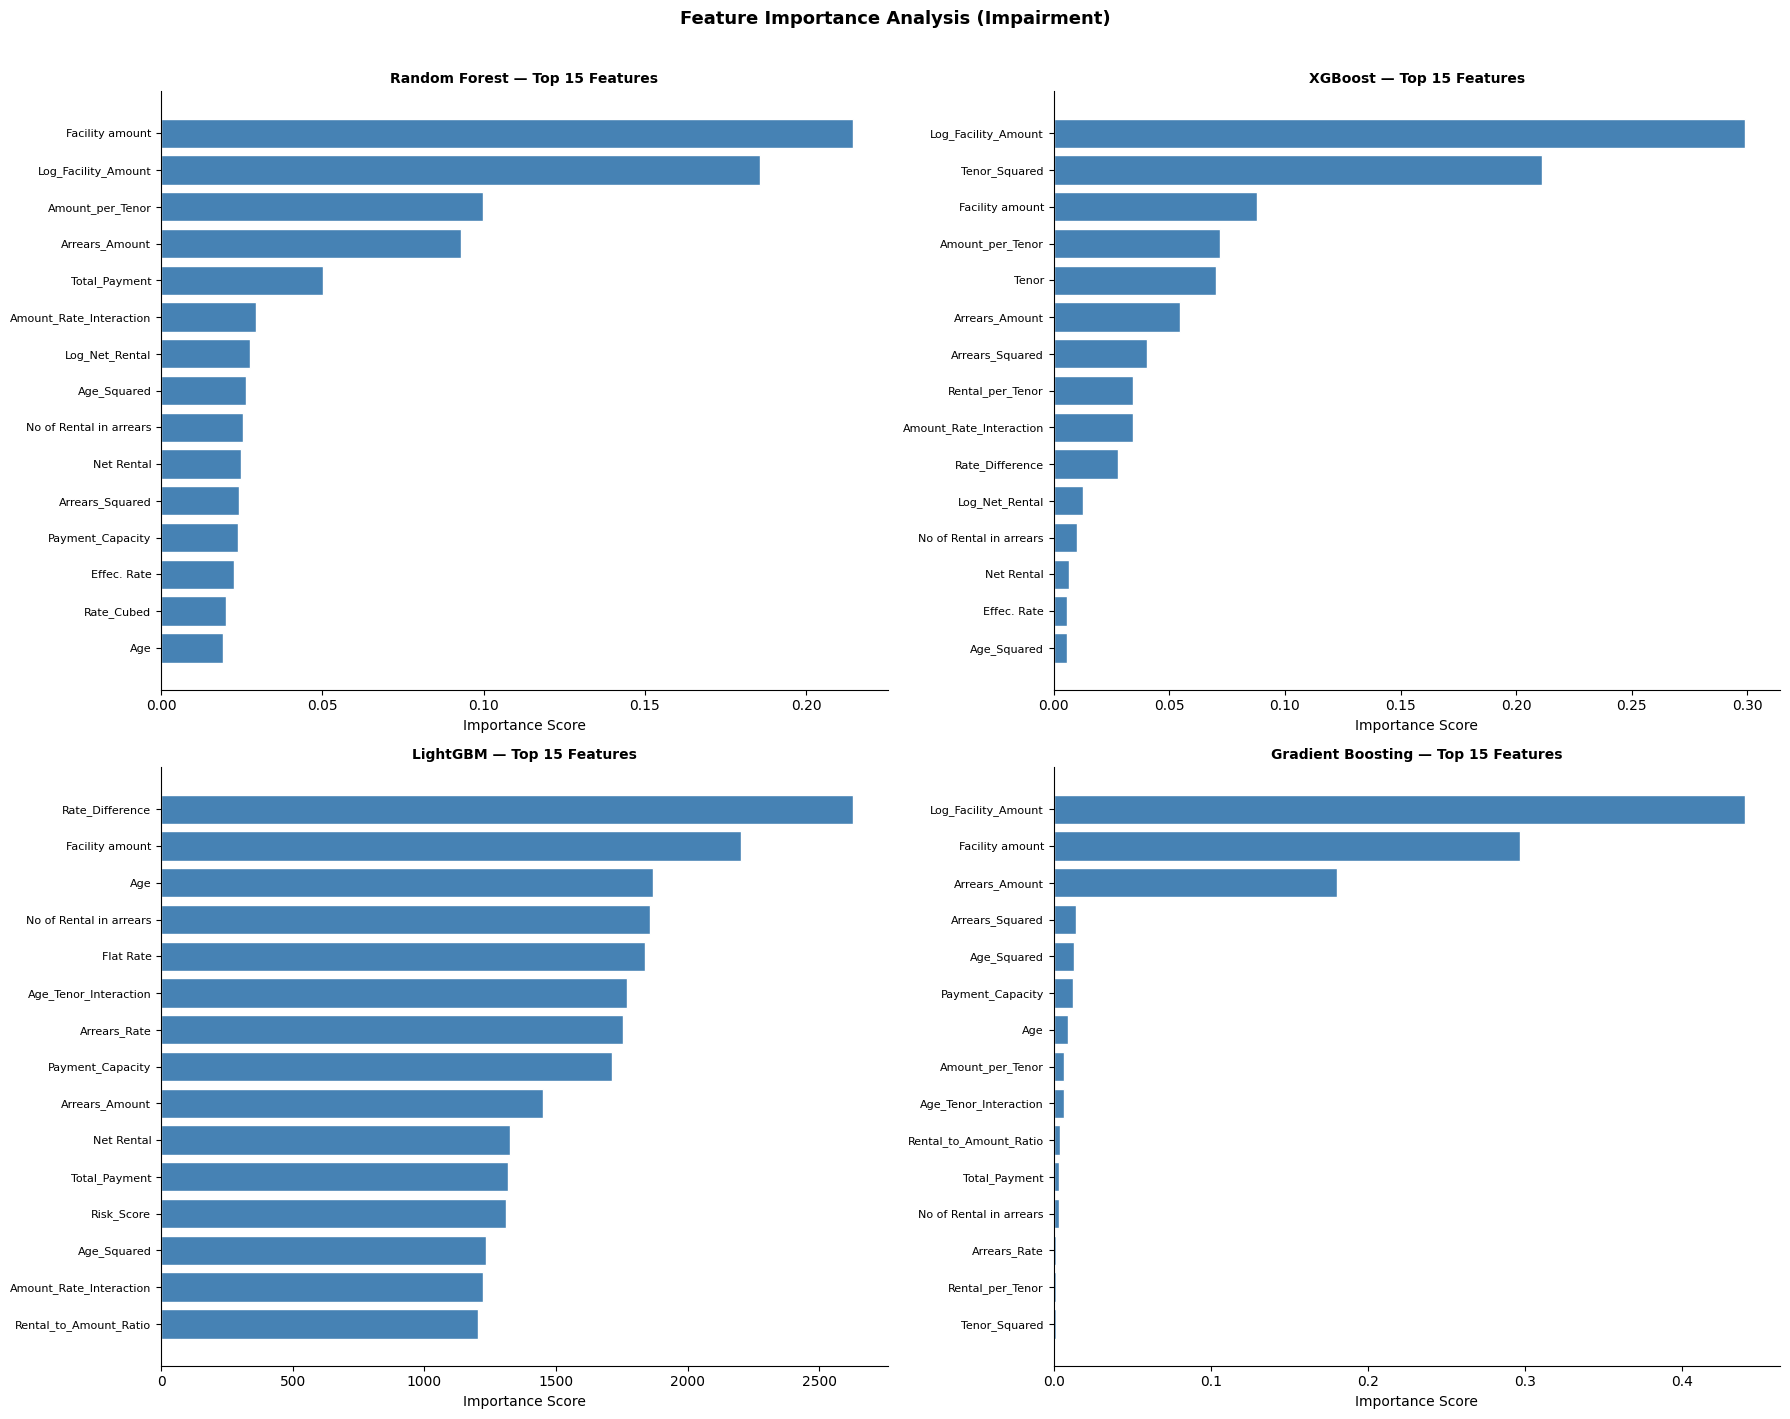

✓ Feature importance chart saved: feature_importance.png


In [8]:

# Feature Importance Analysis
print("\n[5b/7] Feature Importance Analysis (Impairment target)...")

feature_names = list(X_train.columns)
top_n = 15
tree_model_names = ['Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting']
importance_data = {}

for model_name in tree_model_names:
    m = clone(models[model_name])
    m.fit(X_train_scaled, y_imp_train)
    importance_data[model_name] = m.feature_importances_

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (model_name, importances) in enumerate(importance_data.items()):
    top_idx = np.argsort(importances)[-top_n:]
    ax = axes[idx]
    ax.barh(range(top_n), importances[top_idx], color='steelblue', edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in top_idx], fontsize=8)
    ax.set_title(f'{model_name} — Top {top_n} Features', fontsize=10, fontweight='bold')
    ax.set_xlabel('Importance Score')
    sns.despine(ax=ax)

plt.suptitle('Feature Importance Analysis (Impairment)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Feature importance chart saved: feature_importance.png")


In [10]:
# Create ensemble stacking model
print(f"\n{'='*70}")
print("Training ENSEMBLE STACKING MODEL (Meta-Model)")
print(f"{'='*70}")

estimators = [
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ('lgb', LGBMRegressor(n_estimators=200, random_state=42, verbose=-1, n_jobs=-1))
]


Training ENSEMBLE STACKING MODEL (Meta-Model)


In [11]:
# Stacking for Impairment
print(f"\n--- STACKING ENSEMBLE - IMPAIRMENT ---")
stacking_imp = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5
)
stacking_imp.fit(X_train_scaled, y_imp_train)
y_imp_pred_stack = stacking_imp.predict(X_test_scaled)
r2_imp_stack, rmse_imp_stack, mae_imp_stack, mape_imp_stack = evaluate_model(
    y_imp_test, y_imp_pred_stack, "Stacking Ensemble", "Impairment"
)
joblib.dump(stacking_imp, 'stacking_ensemble_impairment.pkl')
print(f"    Model saved: stacking_ensemble_impairment.pkl")


--- STACKING ENSEMBLE - IMPAIRMENT ---

  Stacking Ensemble - Impairment:
    R² Score:     0.990055 (99.01%) ✓ TARGET ACHIEVED
    Adjusted R²:  0.990055
    RMSE:         22131.0445
    MAE:          5590.5704
    MAPE:         154504011544269.34%
    Model saved: stacking_ensemble_impairment.pkl


In [12]:
print(f"\n--- STACKING ENSEMBLE - 1 YR ECL ---")
stacking_ecl = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5
)
stacking_ecl.fit(X_train_scaled, y_ecl_train)
y_ecl_pred_stack = stacking_ecl.predict(X_test_scaled)
r2_ecl_stack, rmse_ecl_stack, mae_ecl_stack, mape_ecl_stack = evaluate_model(
    y_ecl_test, y_ecl_pred_stack, "Stacking Ensemble", "1 yr ECL"
)
joblib.dump(stacking_ecl, 'stacking_ensemble_ecl.pkl')
print(f"    Model saved: stacking_ensemble_ecl.pkl")


--- STACKING ENSEMBLE - 1 YR ECL ---

  Stacking Ensemble - 1 yr ECL:
    R² Score:     0.848742 (84.87%) ⚠ Below target
    Adjusted R²:  0.848741
    RMSE:         7597.9563
    MAE:          3185.4471
    MAPE:         429545155061087.50%
    Model saved: stacking_ensemble_ecl.pkl


In [13]:

results.append({
    'Model': 'Stacking Ensemble', 'Target': 'Impairment',
    'R² Score': r2_imp_stack, 'CV R² Mean': np.nan, 'CV R² Std': np.nan,
    'Accuracy %': r2_imp_stack * 100, 'RMSE': rmse_imp_stack,
    'MAE': mae_imp_stack, 'MAPE %': mape_imp_stack,
    'Status': '✓ Achieved' if r2_imp_stack * 100 >= 95 else '⚠ Below 95%'
})
results.append({
    'Model': 'Stacking Ensemble', 'Target': '1 yr ECL',
    'R² Score': r2_ecl_stack, 'CV R² Mean': np.nan, 'CV R² Std': np.nan,
    'Accuracy %': r2_ecl_stack * 100, 'RMSE': rmse_ecl_stack,
    'MAE': mae_ecl_stack, 'MAPE %': mape_ecl_stack,
    'Status': '✓ Achieved' if r2_ecl_stack * 100 >= 95 else '⚠ Below 95%'
})


In [14]:

# Optuna Hyperparameter Tuning — XGBoost (Impairment)
print("\n[5c/7] Optuna hyperparameter tuning for XGBoost (Impairment)...")
print("       Running 50 trials — this may take a few minutes...")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 800),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'n_jobs': -1
    }
    score = cross_val_score(
        XGBRegressor(**params), X_train_scaled, y_imp_train,
        cv=3, scoring='r2', n_jobs=-1
    ).mean()
    return score

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✓ Best Optuna XGBoost CV R²: {study.best_value:.6f}")
print(f"  Best params: {study.best_params}")

# Retrain with best params
best_xgb_imp = XGBRegressor(**study.best_params)
best_xgb_imp.fit(X_train_scaled, y_imp_train)
y_pred_tuned = best_xgb_imp.predict(X_test_scaled)
r2_tuned, rmse_tuned, mae_tuned, mape_tuned = evaluate_model(
    y_imp_test, y_pred_tuned, "XGBoost (Optuna Tuned)", "Impairment",
    n_features=X_train_scaled.shape[1]
)
joblib.dump(best_xgb_imp, 'xgboost_tuned_impairment.pkl')
print("  Model saved: xgboost_tuned_impairment.pkl")

results.append({
    'Model': 'XGBoost (Optuna Tuned)', 'Target': 'Impairment',
    'R² Score': r2_tuned, 'CV R² Mean': study.best_value, 'CV R² Std': 0.0,
    'Accuracy %': r2_tuned * 100, 'RMSE': rmse_tuned, 'MAE': mae_tuned, 'MAPE %': mape_tuned,
    'Status': '✓ Achieved' if r2_tuned * 100 >= 95 else '⚠ Below 95%'
})



[5c/7] Optuna hyperparameter tuning for XGBoost (Impairment)...
       Running 50 trials — this may take a few minutes...


Best trial: 41. Best value: 0.984662: 100%|██████████| 50/50 [13:18<00:00, 15.97s/it]



✓ Best Optuna XGBoost CV R²: 0.984662
  Best params: {'n_estimators': 657, 'max_depth': 5, 'learning_rate': 0.08421219718304562, 'subsample': 0.9425347072723594, 'colsample_bytree': 0.9353422440830658, 'reg_alpha': 0.17659421649298437, 'reg_lambda': 4.51425567267747, 'min_child_weight': 3}

  XGBoost (Optuna Tuned) - Impairment:
    R² Score:     0.990505 (99.05%) ✓ TARGET ACHIEVED
    Adjusted R²:  0.990502
    RMSE:         21625.0546
    MAE:          6845.2514
    MAPE:         198077011628121.59%
  Model saved: xgboost_tuned_impairment.pkl



[6/7] Generating results summary...

COMPLETE RESULTS SUMMARY

                  Model     Target  R² Score  CV R² Mean  Accuracy %         RMSE          MAE       MAPE %      Status
     Stacking Ensemble   1 yr ECL  0.848742         NaN   84.874213  7597.956275  3185.447053 4.295452e+14 ⚠ Below 95%
         Random Forest   1 yr ECL  0.844826    0.841096   84.482627  7695.678305  3118.666383 4.031726e+14 ⚠ Below 95%
              LightGBM   1 yr ECL  0.840230    0.836659   84.022971  7808.827100  3471.040355 4.568372e+14 ⚠ Below 95%
               XGBoost   1 yr ECL  0.835522    0.832789   83.552211  7923.034782  3511.593062 4.569982e+14 ⚠ Below 95%
     Gradient Boosting   1 yr ECL  0.827447    0.824091   82.744671  8115.203677  3674.666002 4.741701e+14 ⚠ Below 95%
              CatBoost   1 yr ECL  0.821444    0.818591   82.144408  8255.149111  3722.035370 4.827436e+14 ⚠ Below 95%
    Ridge (Polynomial)   1 yr ECL  0.685495    0.682333   68.549540 10955.981720  5970.820225 7.048625

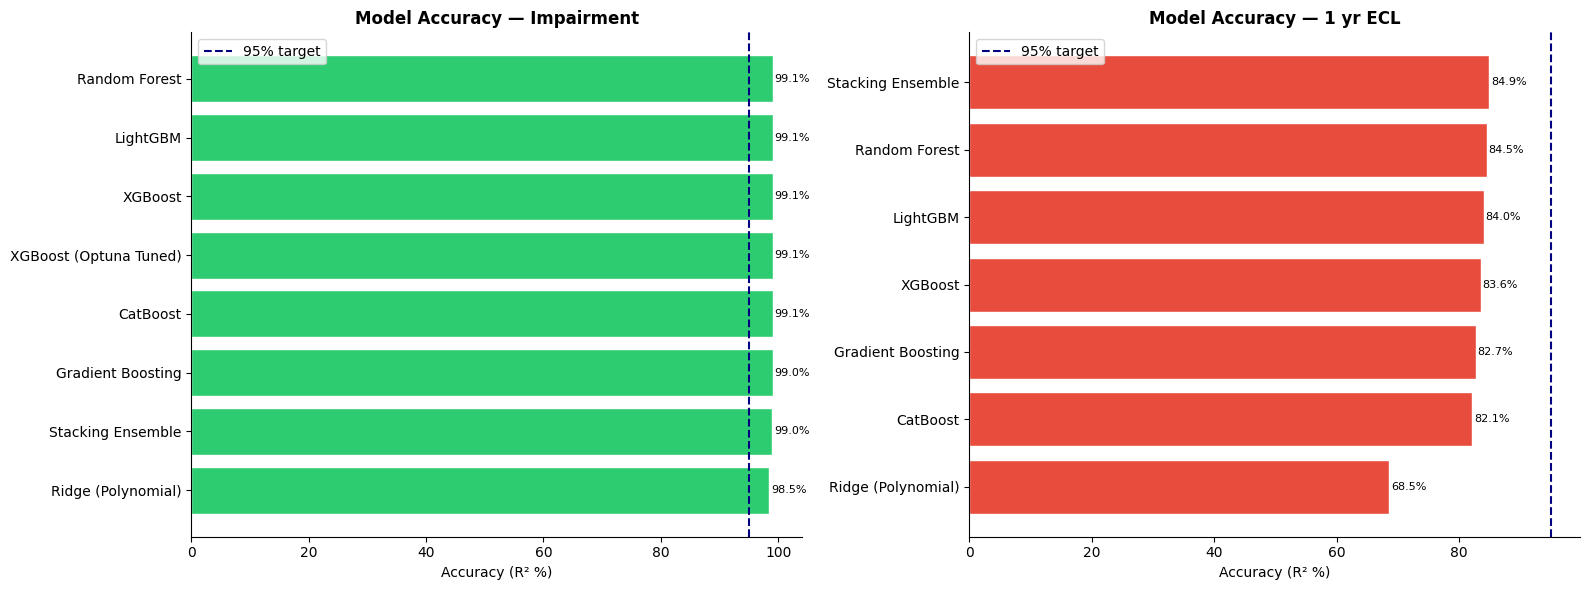

✓ Comparison chart saved: model_comparison.png

[7/7] Process complete!

ALL MODELS TRAINED AND EXPORTED SUCCESSFULLY!

📦 EXPORTED FILES:
   • 15 model files (.pkl)
   • scaler_advanced.pkl
   • advanced_model_results.csv
   • feature_importance.png
   • model_comparison.png

💡 USAGE EXAMPLE:

# Load model and scaler
import joblib
scaler = joblib.load('scaler_advanced.pkl')
model = joblib.load('xgboost_tuned_impairment.pkl')  # Use best model

# Prepare new data (must match training features exactly)
new_data = pd.DataFrame({...})  # Add all features

# Scale and predict
new_data_scaled = scaler.transform(new_data)
prediction = model.predict(new_data_scaled)
print(f'Prediction: {prediction[0]}')



: 

In [ ]:

# Results summary
print("\n[6/7] Generating results summary...")
print(f"\n{'='*70}")
print("COMPLETE RESULTS SUMMARY")
print(f"{'='*70}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['Target', 'Accuracy %'], ascending=[True, False])

display_cols = ['Model', 'Target', 'R² Score', 'CV R² Mean', 'Accuracy %', 'RMSE', 'MAE', 'MAPE %', 'Status']
print("\n", results_df[display_cols].to_string(index=False))

# Save results
results_df.to_csv('advanced_model_results.csv', index=False)
print(f"\n✓ Results saved: advanced_model_results.csv")

# Best models
print(f"\n{'='*70}")
print("BEST PERFORMING MODELS")
print(f"{'='*70}")

best_imp = results_df[results_df['Target'] == 'Impairment'].iloc[0]
best_ecl = results_df[results_df['Target'] == '1 yr ECL'].iloc[0]

print(f"\n🏆 BEST FOR IMPAIRMENT:")
print(f"   Model: {best_imp['Model']}")
print(f"   Accuracy: {best_imp['Accuracy %']:.2f}%")
print(f"   Status: {best_imp['Status']}")

print(f"\n🏆 BEST FOR 1 YR ECL:")
print(f"   Model: {best_ecl['Model']}")
print(f"   Accuracy: {best_ecl['Accuracy %']:.2f}%")
print(f"   Status: {best_ecl['Status']}")

# Models achieving 95%+
achieving_target = results_df[results_df['Accuracy %'] >= 95]
if len(achieving_target) > 0:
    print(f"\n✓ {len(achieving_target)} model(s) achieved 95%+ accuracy:")
    for _, row in achieving_target.iterrows():
        print(f"   • {row['Model']} ({row['Target']}): {row['Accuracy %']:.2f}%")
else:
    print("\n⚠ No models achieved 95%+ accuracy yet.")
    print("   Consider:")
    print("   1. Check if Impairment/ECL are highly correlated with input features")
    print("   2. Add domain-specific features")
    print("   3. Check for data quality issues")
    print("   4. Review Optuna tuning results above")

# Accuracy comparison chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, target in zip(axes, ['Impairment', '1 yr ECL']):
    subset = results_df[results_df['Target'] == target].sort_values('Accuracy %')
    colors = ['#2ecc71' if v >= 95 else '#e74c3c' for v in subset['Accuracy %']]
    bars = ax.barh(subset['Model'], subset['Accuracy %'], color=colors, edgecolor='white')
    ax.axvline(x=95, color='navy', linestyle='--', linewidth=1.5, label='95% target')
    ax.set_xlabel('Accuracy (R² %)')
    ax.set_title(f'Model Accuracy — {target}', fontweight='bold')
    ax.legend()
    for bar, v in zip(bars, subset['Accuracy %']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{v:.1f}%', va='center', fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Comparison chart saved: model_comparison.png")

print(f"\n[7/7] Process complete!")
print(f"\n{'='*70}")
print("ALL MODELS TRAINED AND EXPORTED SUCCESSFULLY!")
print(f"{'='*70}")

print("\n📦 EXPORTED FILES:")
print(f"   • {len(results_df)} model files (.pkl)")
print("   • scaler_advanced.pkl")
print("   • advanced_model_results.csv")
print("   • feature_importance.png")
print("   • model_comparison.png")

print("\n💡 USAGE EXAMPLE:")
print("""
# Load model and scaler
import joblib
scaler = joblib.load('scaler_advanced.pkl')
model = joblib.load('xgboost_tuned_impairment.pkl')  # Use best model

# Prepare new data (must match training features exactly)
new_data = pd.DataFrame({...})  # Add all features

# Scale and predict
new_data_scaled = scaler.transform(new_data)
prediction = model.predict(new_data_scaled)
print(f'Prediction: {prediction[0]}')
""")
